## Predikcija sekundarne strukture proteina primenom CNN+LSTM arhitekture i evolutivnih metoda optimizacije
-------
#### Sara Stojkov SV38/2023

Skup podataka koji će biti korišćen nalazi se na sledećem linku:
- CB513: https://www.kaggle.com/datasets/moklesur/cb513-dataset-for-protein-structure-prediction
- PSS (Protein Secondary Structure): https://www.kaggle.com/datasets/kirkdco/protein-secondary-structure-2022/data

CB513 dataset je u specifičnom .npy obliku - binarnom fajlu koji generiše numpy biblioteka i koji služi za čuvanje velikih array struktura podataka.
PSS je u csv formatu, pogodan za obradu.

Detaljniji opis strukture dataseta može se naći u ovom repozitorijumu: https://github.com/taneishi/CB513_dataset 


In [36]:
# ovo pokrenuti samo jednom, služi da prebaci dataset u format za python 3

import numpy as np

data = np.load('data/CB513.npy', allow_pickle=True, encoding='latin1')

np.save('data/CB513.npy', data)

print("File has been successfully converted to the correct format for python 3")
# ako ne izađe greška, znači da je sve u redu i da se može koristiti dataset u python 3

File has been successfully converted to the correct format for python 3


### 1. Učitavanje podataka / Eksplorativna analiza i vizuelizacija

In [37]:
from helpers.data_utils import load_csv_dataset

df = load_csv_dataset("data/2022-08-06-pdb-intersect-pisces_pc25_r2.5.csv")

print("Number of sequences:", len(df))
print(df.head(3))
print("\nExample sequence:", df.iloc[0]["seq"][:50])
print("Example sst3:     ", df.iloc[0]["sst3"][:50])
print("\nStatistics of sequence lengths:")
print(df["len"].describe())

Number of sequences: 9646
                                        seq  \
0  DTLDEAERQWKAEFHRWSSYMVHWKNQFDHYSKQDRCSDL   
1  KERQKVVEQMEHEMKEAAKALDFERAAELRDLLLELKAEG   
2  LAMPAAERLMQEKGVSPAEVQGTGLGGRILKEDVMRHLEE   

                                       sst3  len  
0  CCCCCHHHHHHHHHHHHHHHHHHHHHHCCCCCCCCCCCCC   40  
1  CHHHHHHHHHHHHHHHHHHCCCHHHHHHHHHHHHHHHCCC   40  
2  CCCHHHHHHHHHCCCCCCCCCCCCCCCCCCHHHHCCCCCC   40  

Example sequence: DTLDEAERQWKAEFHRWSSYMVHWKNQFDHYSKQDRCSDL
Example sst3:      CCCCCHHHHHHHHHHHHHHHHHHHHHHCCCCCCCCCCCCC

Statistics of sequence lengths:
count    9646.000000
mean      262.774103
std       161.918742
min        40.000000
25%       145.000000
50%       229.000000
75%       342.000000
max      2128.000000
Name: len, dtype: float64


In [38]:
from sklearn.model_selection import train_test_split
from helpers.data_utils import dataframe_to_tensors

MAX_LEN = 400  

train_df, val_df = train_test_split(df, test_size=0.05, random_state=42)

X_train, y_train, mask_train = dataframe_to_tensors(train_df, MAX_LEN)
X_val, y_val, mask_val = dataframe_to_tensors(val_df, MAX_LEN)

print("Train:", X_train.shape, y_train.shape, mask_train.shape)
print("Val:  ", X_val.shape, y_val.shape, mask_val.shape)

# provera da maska ima smisla
print("Average percentage of 'real' positions (train):", mask_train.mean())

Train: (9163, 400, 21) (9163, 400) (9163, 400)
Val:   (483, 400, 21) (483, 400) (483, 400)
Average percentage of 'real' positions (train): 0.6007798


In [39]:
data = np.load("data/CB513.npy")
print("Shape:", data.shape)
print("Min/Max values:", data.min(), data.max())
print("Average values of the first position of the first protein:")
print(data[0, 0, :30].mean() if data.ndim == 3 else data[0, :30].mean())

Shape: (514, 39900)
Min/Max values: 0.0 1.0
Average values of the first position of the first protein:
0.06666666666666667


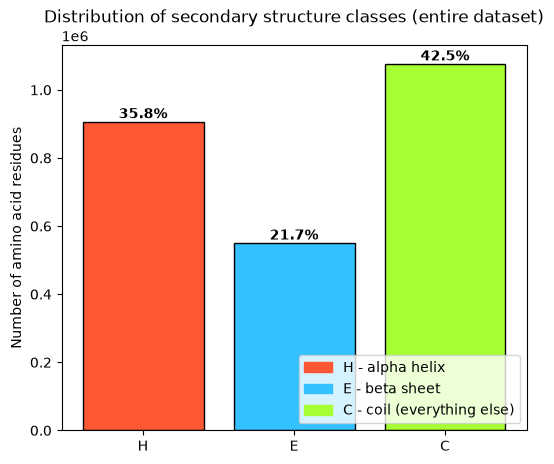

In [46]:
from collections import Counter
import matplotlib.patches as mpatches

all_chars = Counter("".join(df["sst3"].tolist()))
labels_order = ["H", "E", "C"]
counts = [all_chars[l] for l in labels_order]
total = sum(counts)
percentages = [c/total*100 for c in counts]
colors = ["#FF5733", "#33C1FF", "#A6FF33"]

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(labels_order, counts, color=colors, edgecolor="black")
for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{pct:.1f}%",
            ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Number of amino acid residues")
ax.set_title("Distribution of secondary structure classes (entire dataset)")

legend_labels = {
    "H": "H - alpha helix",
    "E": "E - beta sheet",
    "C": "C - coil (everything else)",
}
patches = [mpatches.Patch(color=colors[i], label=legend_labels[l]) for i, l in enumerate(labels_order)]
ax.legend(handles=patches, loc="lower right")

plt.show()

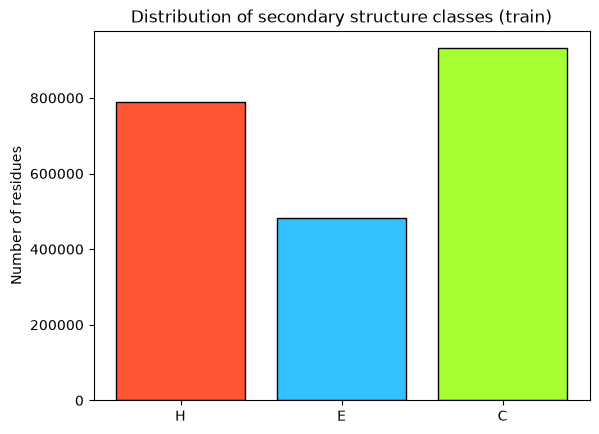

{'H': np.int64(788925), 'E': np.int64(481979), 'C': np.int64(931074)}


In [ ]:
import matplotlib.pyplot as plt

all_labels = y_train[mask_train == 1]
unique, counts = np.unique(all_labels, return_counts=True)
labels_names = ["H", "E", "C"]

plt.bar([labels_names[i] for i in unique], counts, color=["#FF5733", "#33C1FF", "#A6FF33"], edgecolor="black")
plt.title("Distribution of secondary structure classes (train)")
plt.ylabel("Number of residues")
plt.show()

print(dict(zip([labels_names[i] for i in unique], counts)))

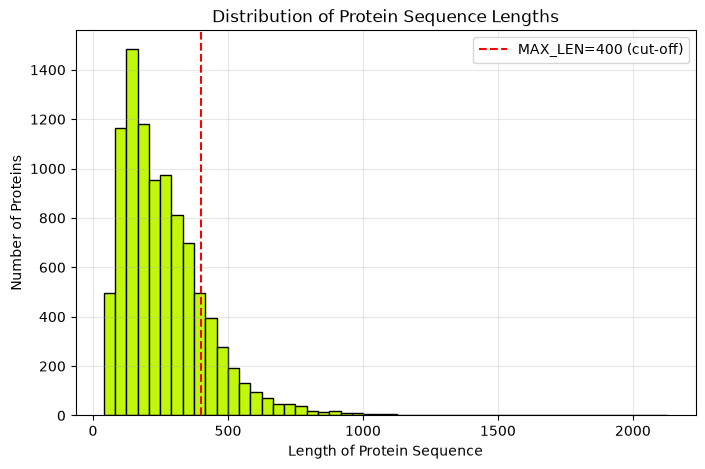

Percentage of proteins longer than 400: 16.1%


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df["len"], bins=50, edgecolor="black", color="#C1F80A")
plt.xlabel("Length of Protein Sequence")
plt.ylabel("Number of Proteins")
plt.title("Distribution of Protein Sequence Lengths")
plt.axvline(400, color="red", linestyle="--", label="MAX_LEN=400 (cut-off)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Percentage of proteins longer than 400: {(df['len'] > 400).mean()*100:.1f}%")

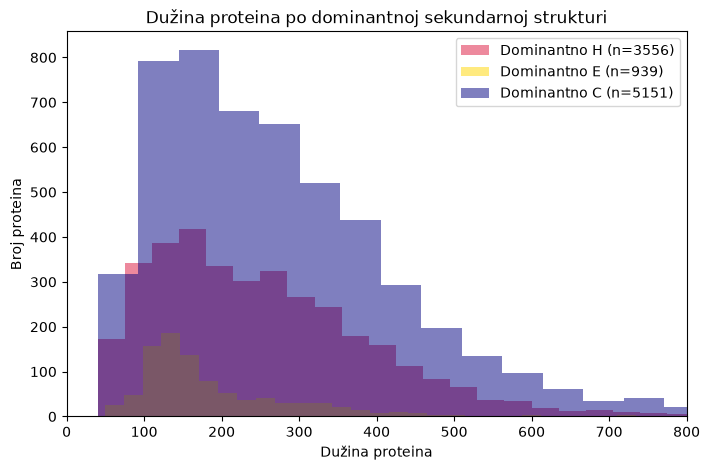

In [ ]:
import numpy as np

def dominant_class(sst3_string):
    c = Counter(sst3_string)
    return c.most_common(1)[0][0]

df["dominant_ss"] = df["sst3"].apply(dominant_class)

plt.figure(figsize=(8, 5))
for label, color in zip(["H", "E", "C"], ["#FF5733", "#33C1FF", "#A6FF33"]):
    subset = df[df["dominant_ss"] == label]["len"]
    plt.hist(subset, bins=40, alpha=0.5, label=f"Dominant {label} (n={len(subset)})", color=color)
plt.xlabel("Length of Protein Sequence")
plt.ylabel("Number of Proteins")
plt.title("Length of Proteins by Dominant Secondary Structure")
plt.legend()
plt.xlim(0, 800)
plt.show()

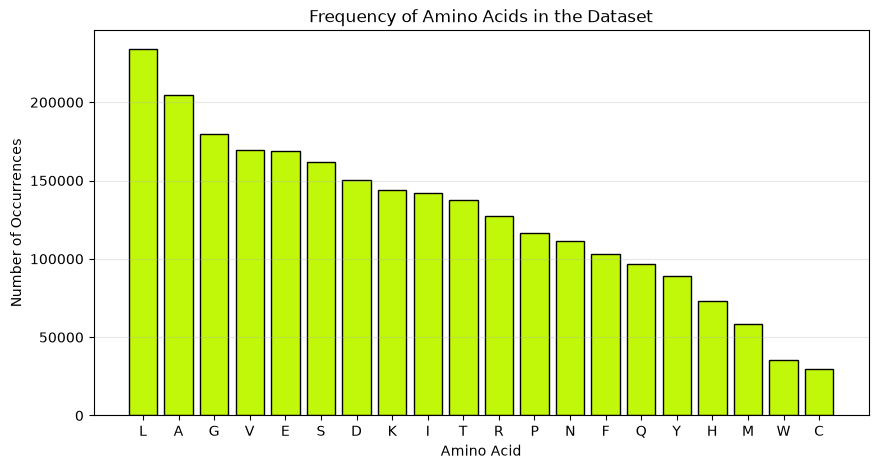

In [ ]:
aa_counts = Counter("".join(df["seq"].str.replace("*", "", regex=False).tolist()))
aa_sorted = sorted(aa_counts.items(), key=lambda x: -x[1])
aas, counts = zip(*aa_sorted)

plt.figure(figsize=(10, 5))
plt.bar(aas, counts, color="#C1F80A", edgecolor="black")
plt.xlabel("Amino Acid")
plt.ylabel("Number of Occurrences")
plt.title("Frequency of Amino Acids in the Dataset")
plt.grid(axis="y", alpha=0.3)
plt.show()

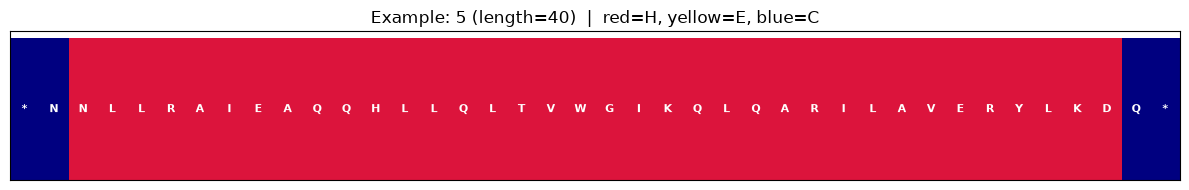

In [ ]:
# example visualization of a single protein sequence with its secondary structure

example = df.iloc[5]  
seq = example["seq"]
sst3 = example["sst3"]

color_map = {"H": "#FF5733", "E": "#33C1FF", "C": "#A6FF33"}
colors = [color_map[c] for c in sst3]

fig, ax = plt.subplots(figsize=(min(len(seq)*0.3, 20), 2))
ax.bar(range(len(seq)), [1]*len(seq), color=colors, width=1.0)
for i, aa in enumerate(seq):
    ax.text(i, 0.5, aa, ha="center", va="center", fontsize=8, color="white", fontweight="bold")
ax.set_xlim(-0.5, len(seq)-0.5)
ax.set_yticks([])
ax.set_xticks([])
ax.set_title(f"Example: {example.name} (length={len(seq)})  |  red=H, yellow=E, blue=C")
plt.tight_layout()
plt.show()

### 2. Treniranje CNN+LSTM modela i evaluacija


In [ ]:
from helpers.model import CNNLSTMModel
import torch

m = CNNLSTMModel()
test_input = torch.randn(4, 400, 21)  # batch=4, seq_len=400, input_dim=21
out = m(test_input)
print(out.shape)  # expected output shape: (4, 400, 3)

torch.Size([4, 400, 3])


In [ ]:
from helpers.train import train_model

test_hp = {"n_filters": 32, "kernel_size": 5, "lstm_units": 64,
           "dropout": 0.3, "lr": 0.001, "batch_size": 32}

acc = train_model(test_hp, X_train, y_train, mask_train,
                   X_val, y_val, mask_val, max_epochs=2)
print("Val Q3 accuracy after 2 epochs:", acc)

acc2 = train_model(test_hp, X_train, y_train, mask_train,
                   X_val, y_val, mask_val, max_epochs=3)

print("Val Q3 accuracy after 3 epochs:", acc2)

Val Q3 accuracy after 2 epochs: 0.6912885999946865
Val Q3 accuracy after 3 epochs: 0.692882634762356


Nakon svega 2 epohe, model dostiže Q3 tačnost od 69.1%, značajno iznad baseline-a od predviđanja isključivo dominantne klase (klase C tj. coil koja ima frekvenciju ~42%). Ovo potvrđuje da pipeline za trening ispravno funkcioniše.

Nakon 3 epohe, model dostiže Q3 tačnost od 69.3%, što je takođe dosta dobro. 

### 3. Metode optimizacije

In [ ]:
from helpers.optimizers.random_search import random_search

N_EVALS = 8  # same number for all algorithms for fair comparison

rs_config, rs_acc, rs_history = random_search(
    n_iter=N_EVALS,
    X_train=X_train, y_train=y_train, mask_train=mask_train,
    X_val=X_val, y_val=y_val, mask_val=mask_val,
    max_epochs=3
)
print("\nBest Random Search config:", rs_config)
print("Best accuracy:", rs_acc)

[RandomSearch 1/8] acc=0.7062 config={'n_filters': 53, 'kernel_size': np.int64(3), 'lstm_units': 199, 'dropout': 0.251336564506643, 'lr': 0.00847588518567691, 'batch_size': np.int64(32)}
[RandomSearch 2/8] acc=0.7108 config={'n_filters': 84, 'kernel_size': np.int64(7), 'lstm_units': 100, 'dropout': 0.34823433006221105, 'lr': 0.0007020990975915224, 'batch_size': np.int64(16)}
[RandomSearch 3/8] acc=0.6914 config={'n_filters': 17, 'kernel_size': np.int64(7), 'lstm_units': 60, 'dropout': 0.19846029106876306, 'lr': 0.0006491027837515655, 'batch_size': np.int64(64)}
[RandomSearch 4/8] acc=0.6948 config={'n_filters': 72, 'kernel_size': np.int64(3), 'lstm_units': 42, 'dropout': 0.12808016923163695, 'lr': 0.0007293464351508947, 'batch_size': np.int64(16)}
[RandomSearch 5/8] acc=0.7138 config={'n_filters': 107, 'kernel_size': np.int64(5), 'lstm_units': 171, 'dropout': 0.19239519892802717, 'lr': 0.0009271352301305275, 'batch_size': np.int64(32)}
[RandomSearch 6/8] acc=0.6952 config={'n_filters':

In [56]:
from helpers.optimizers.genetic_algorithm import genetic_algorithm

ga_config, ga_acc, ga_history = genetic_algorithm(
    pop_size=4, n_generations=2,  # 4*2=8 evaluations in total, comparable to N_EVALS
    X_train=X_train, y_train=y_train, mask_train=mask_train,
    X_val=X_val, y_val=y_val, mask_val=mask_val,
    max_epochs=3
)
print("\nBest GA config:", ga_config)
print("Best accuracy:", ga_acc)

[GA] Gen 0 | best so far: 0.7192
[GA] Gen 1 | best this gen: 0.7197 | best overall: 0.7197
[GA] Gen 2 | best this gen: 0.7186 | best overall: 0.7197

Best GA config: {'n_filters': 92, 'kernel_size': np.int64(5), 'lstm_units': 179, 'dropout': 0.2422478414286939, 'lr': 0.0016666563380906422, 'batch_size': np.int64(16)}
Best accuracy: 0.7197244091001673


In [60]:
from helpers.optimizers.pso import pso

pso_config, pso_acc, pso_history = pso(
    n_particles=4, n_iterations=4,  
    X_train=X_train, y_train=y_train, mask_train=mask_train,
    X_val=X_val, y_val=y_val, mask_val=mask_val,
    max_epochs=3
)
print("\nBest PSO config:", pso_config)
print("Best accuracy:", pso_acc)

[PSO] Iter 1/4 | best so far: 0.6946
[PSO] Iter 2/4 | best so far: 0.7027
[PSO] Iter 3/4 | best so far: 0.7123
[PSO] Iter 4/4 | best so far: 0.7139

Best PSO config: {'n_filters': 102, 'kernel_size': 7, 'lstm_units': 143, 'dropout': 0.1, 'lr': 0.0005189193474018485, 'batch_size': 16}
Best accuracy: 0.7138884707007555


In [ ]:
from helpers.optimizers.bayesian_opt import bayesian_optimization

bayes_config, bayes_acc, bayes_history = bayesian_optimization(
    n_calls=10, # the first param has to be at least 10 for gp_minimize to work properly
    X_train=X_train, y_train=y_train, mask_train=mask_train,
    X_val=X_val, y_val=y_val, mask_val=mask_val,
    max_epochs=3
)
print("\nBest Bayes config:", bayes_config)
print("Best accuracy:", bayes_acc)

[Bayes] eval 1/10 | acc=0.7130 | config={'n_filters': np.int64(105), 'kernel_size': 3, 'lstm_units': np.int64(207), 'dropout': 0.33874006317859484, 'lr': 0.0007792297153882995, 'batch_size': 16}
[Bayes] eval 2/10 | acc=0.6376 | config={'n_filters': np.int64(67), 'kernel_size': 5, 'lstm_units': np.int64(64), 'dropout': 0.36035538917954124, 'lr': 0.00012966511753760403, 'batch_size': 64}
[Bayes] eval 3/10 | acc=0.7148 | config={'n_filters': np.int64(121), 'kernel_size': 3, 'lstm_units': np.int64(254), 'dropout': 0.34699260385108666, 'lr': 0.0016722697006183672, 'batch_size': 16}
[Bayes] eval 4/10 | acc=0.7101 | config={'n_filters': np.int64(19), 'kernel_size': 5, 'lstm_units': np.int64(122), 'dropout': 0.11866626528544619, 'lr': 0.008861577452533074, 'batch_size': 16}
[Bayes] eval 5/10 | acc=0.6879 | config={'n_filters': np.int64(26), 'kernel_size': 5, 'lstm_units': np.int64(118), 'dropout': 0.49329235432271534, 'lr': 0.0008580760619921307, 'batch_size': 64}
[Bayes] eval 6/10 | acc=0.698

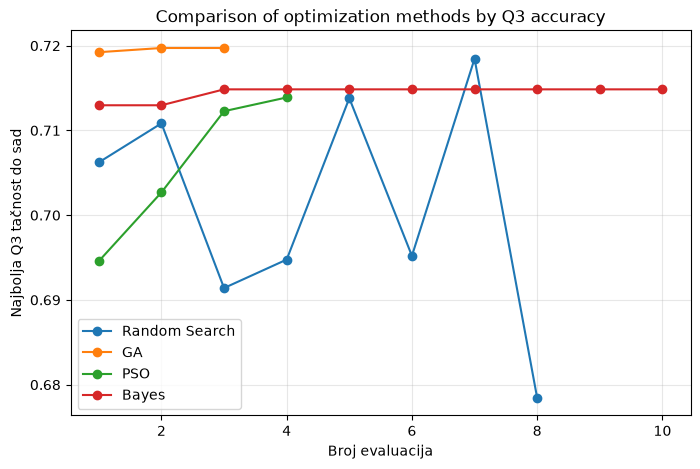

Results: {'Random Search': np.float64(0.7184580370347411), 'GA': np.float64(0.7197244091001673), 'PSO': np.float64(0.7138884707007555), 'Bayes': np.float64(0.7148448915613571)}
Best method: GA


In [61]:
from helpers.visualize import plot_convergence

histories = {
    "Random Search": rs_history,
    "GA": ga_history,
    "PSO": pso_history,
    "Bayes": bayes_history,
}
plot_convergence(histories, title="Comparison of optimization methods by Q3 accuracy")

results_summary = {
    "Random Search": rs_acc, "GA": ga_acc, "PSO": pso_acc, "Bayes": bayes_acc
}
best_method = max(results_summary, key=results_summary.get)
print("Results:", results_summary)
print("Best method:", best_method)

S obzirom na to da je nakon poređenja ovih metoda utvrđeno koji su najbolji hiperparametri, evo provere njihovog Q3 skora:

In [ ]:
from helpers.train import train_model

# Best GA config: {'n_filters': 92, 'kernel_size': np.int64(5), 'lstm_units': 179, 'dropout': 0.2422478414286939, 'lr': 0.0016666563380906422, 'batch_size': np.int64(16)}
# Best accuracy: 0.7197244091001673

test_hp = {"n_filters": 92, "kernel_size": 5, "lstm_units": 179,
           "dropout": 0.2422478414286939, "lr": 0.0016666563380906422, "batch_size": 16}

acc = train_model(test_hp, X_train, y_train, mask_train,
                   X_val, y_val, mask_val, max_epochs=2)

print("Val Q3 accuracy:", acc)

Val Q3 accuracy: 0.7115505530415069


### 4. Provera modela i hiperparametara na CB513 skupu

In [64]:
import numpy as np

data = np.load("data/CB513.npy")
print("Shape:", data.shape)
if data.ndim == 2:
    print("Total values per row:", data.shape[1])

Shape: (514, 39900)
Total values per row: 39900


In [ ]:
from helpers.data_utils import load_cb513

X_test, y_test, mask_test = load_cb513("data/CB513.npy", max_len=MAX_LEN)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("mask_test:", mask_test.shape)
print("Average percentage of valid positions:", mask_test.mean())

print("Unique labels:", np.unique(y_test))

CB513 učitan: 514 proteina, 700 pozicija, 57 vrednosti po poziciji
X_test: (514, 400, 21)
y_test: (514, 400)
mask_test: (514, 400)
Prosečan procenat validnih pozicija: 0.40265563
Unique labele: [-1  0  1  2]


In [ ]:
from helpers.train import train_model

# "winner" config from the previous optimization runs 
best_config = ga_config  

FINAL_EPOCHS = 6 # more than during search (3), since now we train only once

final_acc, final_model = train_model(
    best_config,
    X_train, y_train, mask_train,
    X_val, y_val, mask_val,
    max_epochs=FINAL_EPOCHS,
    return_model=True
)
print("Final Q3 accuracy on CB513 dataset:", final_acc)

In [ ]:
import torch
from helpers.metrics import q3_accuracy, f1_per_class, confusion_matrix_masked

final_model.eval()
with torch.no_grad():
    X_test_t = torch.tensor(X_test, dtype=torch.float32)
    out = final_model(X_test_t)
    test_preds = out.argmax(dim=-1).cpu().numpy()

test_q3 = q3_accuracy(test_preds, y_test, mask_test)
test_f1 = f1_per_class(test_preds, y_test, mask_test)
test_cm = confusion_matrix_masked(test_preds, y_test, mask_test)

print(f"CB513 Q3 accuracy: {test_q3:.4f}")
print(f"F1 per class [H, E, C]: {test_f1}")
print("Confusion matrix:\n", test_cm)

from helpers.visualize import plot_confusion_matrix

plot_confusion_matrix(test_cm, class_names=("H", "E", "C"),
                       title="Confusion matrix — final model on CB513")